In [2]:
# multiome_pipeline.ipynb - Block 1: Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import logging

import scanpy as sc
import anndata as ad
import muon as mu
import mudata as md
from muon import atac as ac

# Silence plotly logs
logging.getLogger("choreographer").setLevel(logging.WARNING)
logging.getLogger("kaleido").setLevel(logging.WARNING)

np.random.seed(42)

# Paths (hub-level for shared reads, WSL native for fragments)
data_dir = Path("/mnt/d/scATAC-seq/data/pbmc_multiome_10k")
sample = "pbmc_granulocyte_sorted_10k"

h5_path      = data_dir / f"{sample}_filtered_feature_bc_matrix.h5"
metrics_path = data_dir / f"{sample}_per_barcode_metrics.csv"

# Fragments on WSL native fs (~10x faster random I/O)
frag_path = Path.home() / "scatac_data" / f"{sample}_atac_fragments.tsv.gz"

assert h5_path.exists(),      f"Missing: {h5_path}"
assert metrics_path.exists(), f"Missing: {metrics_path}"
assert frag_path.exists(),    f"Missing: {frag_path}"

print("Block 1 complete. Paths verified.")


Block 1 complete. Paths verified.


/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [3]:
# Block 2: Load Multiome data

# Read the 10x Multiome h5 (returns MuData with 'rna' and 'atac' modalities)
mdata = mu.read_10x_h5(str(h5_path))

# Make var_names unique per modality (10x sometimes has duplicate gene names)
mdata['rna'].var_names_make_unique()
mdata['atac'].var_names_make_unique()

# Add fragments file to atac modality
ac.tl.locate_fragments(mdata['atac'], fragments=str(frag_path))

# Filter atac to standard chromosomes
# Note: MuData does NOT support item assignment (mdata['atac'] = ...).
# We use the .mod dict directly.
keep = mdata['atac'].var['interval'].str.startswith('chr')
mdata.mod['atac'] = mdata['atac'][:, keep].copy()

# Rebuild MuData from modified modalities
# mdata.update() fails when var_names have been both renamed AND filtered
# (NotImplementedError: no way to restore order). Fresh construction avoids this.
mdata = mu.MuData(mdata.mod)

# Load metadata (not attached to MuData directly, kept for reference)
metadata = pd.read_csv(metrics_path, index_col=0)

# Print summary
# Save raw counts as a layer (Block 5 HVG needs raw; .X gets normalized later)
mdata['rna'].layers['counts'] = mdata['rna'].X.copy()

print(f"Loaded Multiome: {mdata.n_obs} cells")
print(f"  RNA: {mdata['rna'].n_vars} genes")
print(f"  ATAC: {mdata['atac'].n_vars} peaks")
mdata


/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from /mnt/d/scATAC-seq/data/pbmc_multiome_10k/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5


/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packages/mudata/_core/mudata.py:613: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packag

Loaded Multiome: 11898 cells
  RNA: 36601 genes
  ATAC: 143836 peaks


MuData object with n_obs × n_vars = 11898 × 180437
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	11898 × 36601
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
      layers:	'counts'
    atac:	11898 × 143836
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
      uns:	'files'

Fetching Regions...: 100%|██████████| 2000/2000 [00:27<00:00, 73.72it/s] 
/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


RNA obs columns: ['n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt']
ATAC obs columns: ['n_genes_by_counts', 'total_counts', 'nucleosome_signal', 'tss_score']


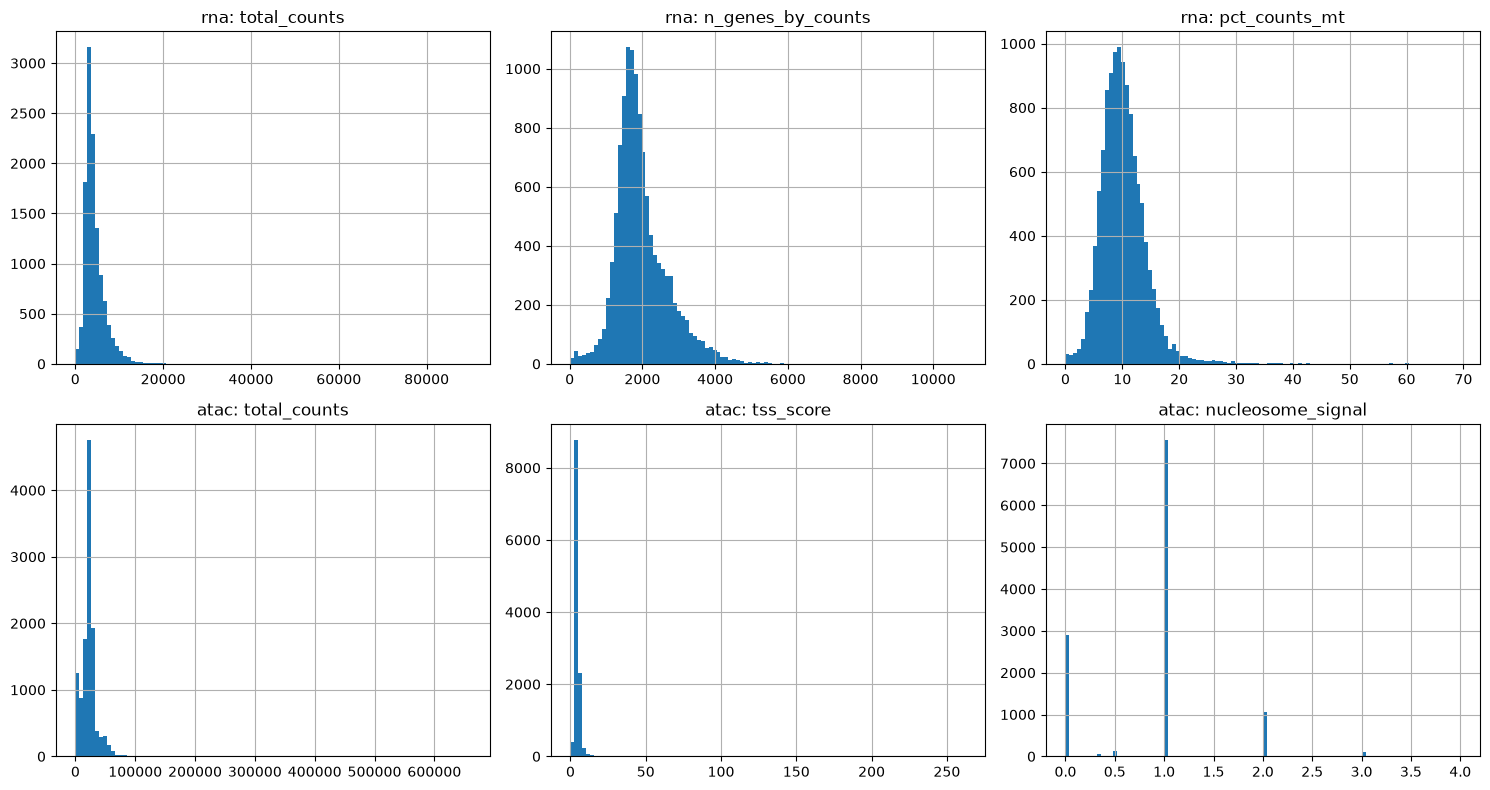

In [4]:
# Block 3: QC per modality

# --- RNA side ---
rna = mdata['rna']
rna.var['mt'] = rna.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], inplace=True, log1p=False)

# --- ATAC side ---
atac = mdata['atac']
# Compute per-cell total counts (muon's tss/nucleosome funcs don't add this)
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
ac.tl.nucleosome_signal(atac, n=10000)
ac.tl.tss_enrichment(atac, features=ac.tl.get_gene_annotation_from_rna(rna))

# Preview
print("RNA obs columns:", list(rna.obs.columns))
print("ATAC obs columns:", list(atac.obs.columns))

# Combined QC plot (matplotlib)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (mod, col) in zip(axes.flat, [
    ('rna', 'total_counts'), ('rna', 'n_genes_by_counts'), ('rna', 'pct_counts_mt'),
    ('atac', 'total_counts'), ('atac', 'tss_score'), ('atac', 'nucleosome_signal'),
]):
    mdata[mod].obs[col].hist(bins=100, ax=ax)
    ax.set_title(f"{mod}: {col}")
plt.tight_layout()
plt.savefig("qc_violin_multiome.png", dpi=150)
plt.show()


In [5]:
# Block 4: Filter cells

n_before = mdata.n_obs

# RNA-side filter
mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= 200) & (x <= 5000))
mu.pp.filter_obs(rna, 'total_counts', lambda x: (x >= 1000) & (x <= 25000))
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x < 20)

# ATAC-side filter
mu.pp.filter_obs(atac, 'total_counts', lambda x: (x >= 1000) & (x <= 100000))
mu.pp.filter_obs(atac, 'tss_score', lambda x: x > 1)
mu.pp.filter_obs(atac, 'nucleosome_signal', lambda x: x < 2)

# Sync: keep only cells present in both modalities
mu.pp.intersect_obs(mdata)

n_after = mdata.n_obs
print(f"Filtered: {n_before} -> {n_after} cells (kept {100 * n_after / n_before:.1f}%)")


Filtered: 11898 -> 10107 cells (kept 84.9%)


/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packages/mudata/_core/mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


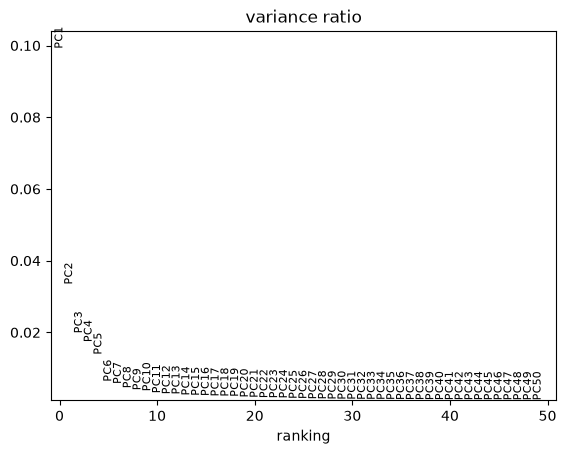

In [6]:
# Block 5: Process RNA (normalize + PCA + UMAP)
# NOTE: seurat_v3 flavor requires RAW counts, so HVG is called BEFORE normalize_total.

# Step 1: Feature selection on raw counts (from 'counts' layer, saved in Block 2)
sc.pp.highly_variable_genes(rna, n_top_genes=2000, flavor='seurat_v3', layer='counts')

# Step 2: Normalize + log
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

# Step 3: Save log1p-normalized in .raw (CellTypist needs this later),
# then scale + PCA
rna.raw = rna.copy()
sc.pp.scale(rna, max_value=10)
sc.tl.pca(rna, n_comps=50)

# Elbow
sc.pl.pca_variance_ratio(rna, n_pcs=50, save="_rna.png")

# UMAP on RNA only
sc.pp.neighbors(rna, n_neighbors=15, n_pcs=30)
sc.tl.umap(rna)


In [7]:
# Block 6: Process ATAC (TF-IDF + LSI + UMAP)

# TF-IDF (muon)
ac.pp.tfidf(atac, scale_factor=1e4)

# SVD
ac.tl.lsi(atac)

# Drop first LSI component (depth confound), same as Signac
atac.obsm['X_lsi'] = atac.obsm['X_lsi'][:, 1:]
atac.varm["LSI"] = atac.varm["LSI"][:, 1:]
atac.uns["lsi"]["stdev"] = atac.uns["lsi"]["stdev"][1:]

# UMAP on ATAC
sc.pp.neighbors(atac, use_rep="X_lsi", n_neighbors=15)
sc.tl.umap(atac)


In [8]:
# Block 7: Joint neighbors (muon's cross-modal weighted NN)

# Cross-modal weighted NN (analog of Seurat WNN)
mu.pp.neighbors(mdata, key_added='wnn')

# UMAP on joint embedding
mu.tl.umap(mdata, neighbors_key='wnn')

# Joint clustering (use scanpy leiden with obsp arg to consume the joint graph;
# mu.tl.leiden expects per-modality graphs, different algorithm)
sc.tl.leiden(
    mdata,
    obsp='wnn_connectivities',
    resolution=0.8,
    key_added='leiden',
    random_state=42,
)

n_clusters = mdata.obs['leiden'].nunique()
print(f"Joint clusters found: {n_clusters}")


/home/bioinfo/miniforge3/envs/scatac-py/lib/python3.11/site-packages/mudata/_core/mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/tmp/ipykernel_2660/18856812.py:11: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


Joint clusters found: 18


In [10]:
# Block 8: Automated annotation with CellTypist + joint UMAP

# Install once: pip install celltypist
import celltypist
from celltypist import models

# Download PBMC-tuned model (~10 MB, cache on first call)
models.download_models(model='Immune_All_Low.pkl', force_update=False)
pbmc_model = models.Model.load(model='Immune_All_Low.pkl')

# Annotate RNA modality
# CellTypist needs log1p-normalized (not scaled) expression.
# If Block 5 saved rna.raw before sc.pp.scale, CellTypist reads from .raw.X automatically.
# If not, create a fresh copy from counts layer:
if rna.raw is None:
    rna_for_annot = rna.copy()
    rna_for_annot.X = rna_for_annot.layers['counts'].copy()
    sc.pp.normalize_total(rna_for_annot, target_sum=1e4)
    sc.pp.log1p(rna_for_annot)
    input_ad = rna_for_annot
else:
    input_ad = rna

predictions = celltypist.annotate(
    input_ad,
    model=pbmc_model,
    majority_voting=True,
    over_clustering=rna.obs['leiden'],
)

# Attach labels to rna, mdata, atac
rna.obs = rna.obs.join(predictions.predicted_labels)
mdata.obs['cell_type'] = rna.obs['majority_voting'].values
atac.obs['cell_type'] = mdata.obs['cell_type'].values
rna.obs['cell_type'] = mdata.obs['cell_type'].values

# Sync leiden for per-modality UMAP color
atac.obs['leiden'] = mdata.obs['leiden'].values

# Three UMAPs comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sc.pl.umap(rna, color='cell_type', ax=axes[0], show=False, title='RNA UMAP')
sc.pl.umap(atac, color='cell_type', ax=axes[1], show=False, title='ATAC UMAP')
mu.pl.umap(mdata, color='cell_type', ax=axes[2], show=False,
           title='WNN joint UMAP (CellTypist annotated)')
plt.tight_layout()
plt.savefig("umap_three_way_annotated.png", dpi=150)

# Confidence
rna.obs['confidence'] = predictions.probability_matrix.max(axis=1).values
sc.settings.figdir = "."
sc.pl.umap(rna, color='confidence', vmin=0, vmax=1,
           save='_celltypist_confidence.png')

# Save
mdata.write("multiome_annotated.h5mu")


📂 Storing models in /home/bioinfo/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


KeyError: 'leiden'